In [2]:
import pandas as pd
import numpy as np
import requests
from io import StringIO
import scipy
import os
import datetime as dt

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Input
import tensorflow_addons as tfa


In [50]:
import sys
sys.version

'3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]'

# Carga de datos

## Datos B/manga (Colombia)

In [3]:

# URL base de la API
base_url_ws_col = "https://www.datos.gov.co/resource/57ur-5p28.csv"

# Parámetros
limit = 1000  # número máximo permitido por la API
offset = 0    # desplazamiento inicial
all_data = [] # lista para almacenar los bloques

csv_file_ws_col = "..\\data\\datos_eh_bcmga_2021.csv"


In [4]:
if os.path.exists(csv_file_ws_col):
    ws_col = pd.read_csv(csv_file_ws_col)
    print("Se carga el archivo csv")
else:
    while True:
        # Construir URL con paginación
        url = f"{base_url_ws_col}?$limit={limit}&$offset={offset}"
        print(f"Descargando: {url}")

        # Hacer la solicitud
        response = requests.get(url)
        
        # Si falla la solicitud, salir
        if response.status_code != 200:
            print(f"Error en la descarga: {response.status_code}")
            break

        # Leer el bloque como DataFrame
        df_chunk = pd.read_csv(StringIO(response.text))
        
        # Si el bloque está vacío, terminamos
        if df_chunk.empty:
            break
        
        # Agregar a la lista
        all_data.append(df_chunk)
        
        # Aumentar el offset para el siguiente bloque
        offset += limit
    # Unir todos los bloques en un solo DataFrame
    ws_col = pd.concat(all_data, ignore_index=True)

    print(f"Total de registros descargados: {len(ws_col)}")

    ws_col.to_csv(csv_file_ws_col, index=False)


Se carga el archivo csv


## Datos Bruselas (Belgica)

In [5]:
url_bel = "https://zenodo.org/records/10723261/files/Weather_data.mat"
mat_file_ws_bel = "..\\data\\Weather_data.mat"

In [6]:
if os.path.exists(mat_file_ws_bel):
    ws_bel = scipy.io.loadmat(mat_file_ws_bel)
    print("Se carga el archivo mat")

else:

    response = requests.get(url_bel)
    # Verificar que la descarga fue exitosa
    if response.status_code == 200:
        with open(mat_file_ws_bel, "wb") as f:
            f.write(response.content)
        print(f"Archivo guardado como: {mat_file_ws_bel}")
        ws_bel = scipy.io.loadmat(mat_file_ws_bel)
        print("Se carga el archivo mat")
    else:
        print(f"Error al descargar: {response.status_code}")

Se carga el archivo mat


In [7]:
# # Extract data from dataset

# WS_data = scipy.io.loadmat(mat_file_ws_bel)
# WS_data.keys()

# Preprocesamiento

## Datos B/manga

In [8]:
# Copia del df original
df_col = ws_col.copy()

En la columna `dir` se cambia los valores cardinales a grados

In [9]:
cardinal_to_deg = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5
}


In [10]:

# Normalizar a string para detectar cardinales
df_col['dir'] = df_col['dir'].astype(str).str.strip().str.upper()

# Convertir cardinales a grados
df_col['dir_deg'] = df_col['dir'].map(cardinal_to_deg)

# Si no es cardinal, intentar convertir a número
df_col['dir_deg'] = df_col['dir_deg'].fillna(pd.to_numeric(df_col['dir'], errors='coerce'))

# Reemplazar valores inválidos
df_col['dir_deg'] = df_col['dir_deg'].replace([-999, -999.0], np.nan)

# Si hay valores > 360, llevarlos al rango [0,360)
df_col['dir_deg'] = df_col['dir_deg'] % 360

Se arregla la columna `bar` que indica la presión registrada

In [11]:
# Reemplazar valores inválidos
df_col['bar'] = df_col['bar'].replace([-999, -999.0], np.nan)

Se arregla la columna `speed` que indica la velocidad del viento registrada

In [12]:
(df_col["speed"].value_counts() / df_col.shape[0]).apply(lambda a: f"{100 * a:.2f} %")

speed
 0.000      32.23 %
-999.000    17.57 %
 0.400      11.99 %
 0.900       6.94 %
 1.300       4.53 %
             ...   
 1.148       0.00 %
 1.472       0.00 %
 1.252       0.00 %
 0.633       0.00 %
 1.525       0.00 %
Name: count, Length: 874, dtype: object

Se toma las columnas `date` y `time` para ser combinadas y obtener la columnas `datetime`

In [13]:
# Supongamos que df_col tiene las columnas 'date' y 'time'
df_col['date'] = pd.to_datetime(df_col['date'])
df_col['time'] = pd.to_datetime(df_col['time']).dt.time  # extraer solo la hora

# Combinar
df_col['datetime'] = df_col.apply(lambda row: pd.Timestamp.combine(row['date'], row['time']), axis=1)


Se elimnan los valores `nan` del dataframe

In [14]:
df_col.shape

(138566, 16)

In [15]:
df_col = df_col.loc[
    ~ df_col["dir_deg"].isna() &
    ~ df_col["bar"].isna()
].copy()

df_col.shape

(77664, 16)

In [16]:
f"Se conserva un totla de {100 * df_col.shape[0] / ws_col.shape[0]:.2f}% de los datos originales"

'Se conserva un totla de 56.05% de los datos originales'

In [39]:
valores , conteo = np.unique(df_col["datetime"].values, return_counts=True)

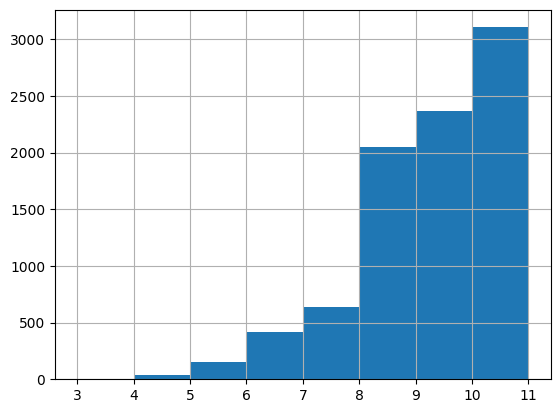

In [47]:
plt.hist(conteo, bins=8)
plt.grid()
plt.show()

In [33]:
df_col["estaci_n"].value_counts()

estaci_n
LA JUDIA                   8265
LAGO ALTO                  8231
PORTUGAL                   7674
EL ROBLE                   7253
TURBAY                     6914
EL DIAMANTE                6791
BETANIA                    5139
EL CAIRO                   4796
EL PANTANO                 4687
LA AGUADA                  4669
ACAPULCO                   4501
EL RASGÓN                  4386
SANTA CRUZ DE LA COLINA    2313
LA NARANJERA               2045
Name: count, dtype: int64

In [34]:
df_col["estaci_n"].nunique()

14

## Procesamiento para la PINN

In [31]:
date_col = df_col['datetime'].copy()
time_init_col = min(date_col)
TC_nan_index = np.argwhere(pd.isna(date_col))
date_col = np.delete(date_col, TC_nan_index[:,0], 0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date_col)))

Double-check for NaN in time sequence 0


In [19]:
seconds_col = np.zeros((date_col.shape[0], 1))
for index in range(date_col.shape[0]):
    seconds_col[index, 0] = ((date_col[index] - time_init_col).total_seconds())
TC_WS = seconds_col 

In [20]:
XC_WS = df_col["coordenada_x"].values
YC_WS = df_col["coordenada_y"].values

In [21]:
UC_WS = df_col['speed'].values * np.cos(df_col["dir_deg"].values*(np.pi/180))
VC_WS = df_col['speed'].values * np.sin(df_col["dir_deg"].values*(np.pi/180))

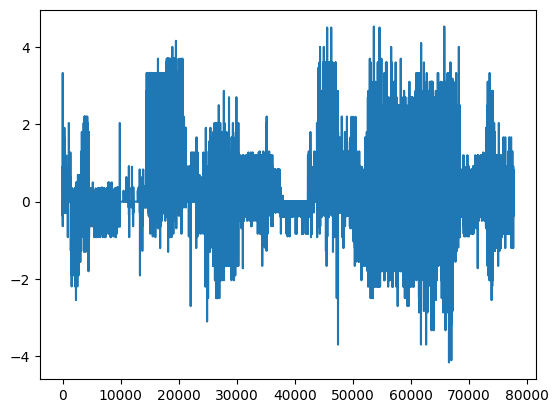

In [24]:
plt.plot(UC_WS)

In [27]:
# Pressure from mbar to Pac
PC_WS = df_col["bar"].values * 100

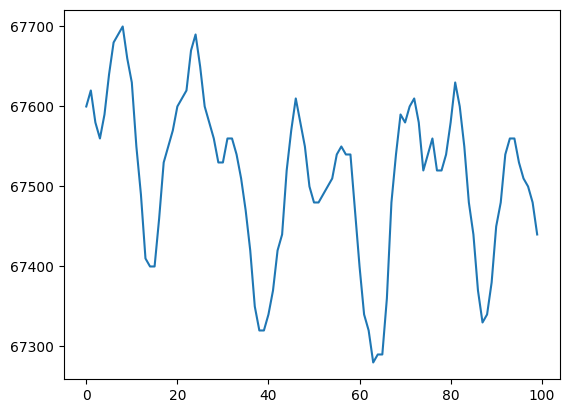

In [29]:
plt.plot(PC_WS[:100])

In [32]:
# Remove NaN values from time field
XC_WS = np.delete(XC_WS, TC_nan_index[:, 0],  0)
YC_WS = np.delete(YC_WS, TC_nan_index[:, 0],  0)
UC_WS = np.delete(UC_WS, TC_nan_index[:, 0],  0)
VC_WS = np.delete(VC_WS, TC_nan_index[:, 0],  0)
PC_WS = np.delete(PC_WS, TC_nan_index[:, 0],  0)

In [158]:
PC_WS

array([67600., 67620., 67580., ..., 58510., 58540., 58530.])

## Datos Bruselas

Se convierte a tiempo continuo: desde el formato decha a segundos

In [55]:
date_0 = ws_bel['Date'][0]
date = []
for i in range(0, len(date_0)):
    date = np.append(date, str(date_0[i])[2 : -2])
time_init = dt.datetime(int(date[0][0 : 4]), int(date[0][5 : 7]), int(date[0][8 : 10]), int(date[0][11 : 13]), int(date[0][14 : 16]))
T_nan_index = np.argwhere(pd.isna(date))
date = np.delete(date, T_nan_index[:, 0],  0)
print('Double-check for NaN in time sequence', np.sum(pd.isna(date)))

Double-check for NaN in time sequence 0


In [56]:
Seconds = np.zeros((date.shape[0], 1))
for index in range(date.shape[0]):
    Seconds[index, 0] = ((dt.datetime(int(date[index][0 : 4]), int(date[index][5 : 7]), int(date[index][8 : 10]), int(date[index][11 : 13]), int(date[index][14 : 16])) - time_init).total_seconds())
T_WS = Seconds

Se convierte a coordenadas cartesianas

In [57]:
X_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lon'])))[0]  # Longitude to meters
Y_WS = np.array(6378000 * np.sin(np.radians(ws_bel['Lat'])))[0]  # Latitude to meters
Z_WS = np.array(ws_bel['Alt'])[0]
Temp_WS = np.array(ws_bel['Temperature'])[0]

Se proyecta la velocidad del viento y la dirección en las coordenadas cartesianas

In [58]:
U_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionX'])[0]
V_WS = (ws_bel['WindSpeed'] * ws_bel['WindDirectionY'])[0]

Presión de mbar a Pa

In [59]:
P_WS = ws_bel['Pressure'][0] * 100

Removiendo valores `NaN`

In [60]:
X_WS = np.delete(X_WS, T_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, T_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, T_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, T_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, T_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, T_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, T_nan_index[:, 0],  0)

In [61]:
T_WS.shape

(42336, 1)

Se estructura la información en una matriz: 21 estaciones `(filas)` $\times$ medidas cada 10 min `(columnas)`

In [62]:
T_WS = np.reshape(T_WS, (int(T_WS.shape[0] / 21), 21)).T # There are 21 WS stations in this case
X_WS = np.reshape(X_WS, (T_WS.shape[1], T_WS.shape[0])).T
Y_WS = np.reshape(Y_WS, (T_WS.shape[1], T_WS.shape[0])).T
Z_WS = np.reshape(Z_WS, (T_WS.shape[1], T_WS.shape[0])).T
U_WS = np.reshape(U_WS, (T_WS.shape[1], T_WS.shape[0])).T
V_WS = np.reshape(V_WS, (T_WS.shape[1], T_WS.shape[0])).T
P_WS = np.reshape(P_WS, (T_WS.shape[1], T_WS.shape[0])).T
Temp_WS = np.reshape(Temp_WS, (T_WS.shape[1], T_WS.shape[0])).T
print('Number of weather stations:', T_WS.shape[0])

Number of weather stations: 21


Se remueven los valores `NaN`

In [63]:
X_nan_index = np.argwhere(np.isnan(X_WS))
T_WS = np.delete(T_WS, X_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, X_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, X_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, X_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, X_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, X_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, X_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, X_nan_index[:, 0],  0)
print('Double-check for NaN in location field', np.sum(np.isnan(X_WS)))

Double-check for NaN in location field 0


Se indica la cantidad de días

In [64]:
n_days = 14 # Change up to a maximum of 14 availsble days
samples =  int(144 * n_days) # Convert selected days to snapshots
T_WS = T_WS[:, : samples]
X_WS = X_WS[:, : samples]
Y_WS = Y_WS[:, : samples]
Z_WS = Z_WS[:, : samples]
U_WS = U_WS[:, : samples]
V_WS = V_WS[:, : samples]
P_WS = P_WS[:, : samples]
Temp_WS = Temp_WS[:, : samples]

Se ordena la matriz con el incremeto de los valores en la coordenada X

In [65]:
for snap in range(0, T_WS.shape[1]):
    index_sort = np.argsort(X_WS[:, snap])
    T_WS[:, snap] = T_WS[index_sort, snap]
    X_WS[:, snap] = X_WS[index_sort, snap]
    Y_WS[:, snap] = Y_WS[index_sort, snap]
    Z_WS[:, snap] = Z_WS[index_sort, snap]
    U_WS[:, snap] = U_WS[index_sort, snap]
    V_WS[:, snap] = V_WS[index_sort, snap]
    P_WS[:, snap] = P_WS[index_sort, snap]
    Temp_WS[:, snap] = Temp_WS[index_sort, snap]

Se eliminan los valores `NaN` de `U`, `V` y `P`

In [66]:
uvp_mean = np.nanmean(np.concatenate([U_WS, V_WS, P_WS], axis = 1), axis = 1)[:, None]
vel_nan_index = np.argwhere(np.isnan(uvp_mean))
T_WS = np.delete(T_WS, vel_nan_index[:, 0],  0)
P_WS = np.delete(P_WS, vel_nan_index[:, 0],  0)
U_WS = np.delete(U_WS, vel_nan_index[:, 0],  0)
V_WS = np.delete(V_WS, vel_nan_index[:, 0],  0)
X_WS = np.delete(X_WS, vel_nan_index[:, 0],  0)
Y_WS = np.delete(Y_WS, vel_nan_index[:, 0],  0)
Z_WS = np.delete(Z_WS, vel_nan_index[:, 0],  0)
Temp_WS = np.delete(Temp_WS, vel_nan_index[:, 0],  0)

Se corrige la presión para el nivel del mar (ISA)

In [67]:
P_WS = P_WS * (1 - 0.0065 * Z_WS / (Temp_WS + 273.15 + 0.0065 * Z_WS))**(-5.257)

Centrando los valores de localización y tiempo

In [68]:
x_min = np.min(X_WS)
x_max = np.max(X_WS)
X_WS = X_WS - (x_min + x_max) / 2
y_min = np.min(Y_WS)
y_max = np.max(Y_WS)
Y_WS = Y_WS - (y_min + y_max) / 2
t_min = np.min(T_WS)
t_max = np.max(T_WS)
T_WS = T_WS - t_min # Refer to t = 0

In [69]:
Y_WS.shape, X_WS.shape, T_WS.shape

print(
    T_WS[1,:9],"\n",
    X_WS[1,:9],"\n",
    Y_WS[1,:9],"\n",
)

[   0.  600. 1200. 1800. 2400. 3000. 3600. 4200. 4800.] 
 [-143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808 -143638.70673808 -143638.70673808 -143638.70673808
 -143638.70673808] 
 [30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582 30967.31993582 30967.31993582 30967.31993582
 30967.31993582] 



### Cuadricula de salida para la PINN

In [70]:
T_PINN = T_WS[0 : 1, :] # Same times for reconstruction

Resolución en grados $R = 0.2$

In [71]:
R = 0.2
R_PINN = 6378000 * np.sin(np.radians(R)) # Grid resolution
x_PINN = np.arange(x_min - R_PINN, x_max + R_PINN, R_PINN) # X values in output resolution
y_PINN = np.arange(y_min - R_PINN, y_max + R_PINN, R_PINN) # Y values in output resolution

Centrando la información de localización

In [72]:
x_PINN = x_PINN - (x_min + x_max) / 2
y_PINN = y_PINN - (y_min + y_max) / 2

In [73]:
x_PINN.shape,y_PINN.shape

((20,), (8,))

Cuadricula de salida final

In [74]:
X_PINN, Y_PINN = np.meshgrid(x_PINN, y_PINN)
X_PINN = X_PINN.flatten('F')[:, None]
Y_PINN = Y_PINN.flatten('F')[:, None]

Dimensiones

In [75]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(1, 2016)
X_PINN.shape=(160, 1)
Y_PINN.shape=(160, 1)


In [76]:
dim_T_PINN = T_PINN.shape[1]
dim_N_PINN = X_PINN.shape[0]

T_PINN = np.tile(T_PINN, (dim_N_PINN, 1))
X_PINN = np.tile(X_PINN, dim_T_PINN)
Y_PINN = np.tile(Y_PINN, dim_T_PINN)

In [77]:
a = np.array(["A", "B"])
b = np.array(["X", "Y", "Z"])
T = np.array([[1 ,2 , 3, 4]])
A , B = np.meshgrid(
    a,
    b,
)
A, B = A.flatten("F")[:,None] , B.flatten("F")[:,None]

dimn = A.shape[0]
dimt = T.shape[1]
T = np.tile(T, (dimn, 1))
A = np.tile(A, dimt)
B = np.tile(B, dimt)
for i in range(T.shape[0]):
    print(f"{A[i,:]}   {B[i,:]}   {T[i,:]}")
        

['A' 'A' 'A' 'A']   ['X' 'X' 'X' 'X']   [1 2 3 4]
['A' 'A' 'A' 'A']   ['Y' 'Y' 'Y' 'Y']   [1 2 3 4]
['A' 'A' 'A' 'A']   ['Z' 'Z' 'Z' 'Z']   [1 2 3 4]
['B' 'B' 'B' 'B']   ['X' 'X' 'X' 'X']   [1 2 3 4]
['B' 'B' 'B' 'B']   ['Y' 'Y' 'Y' 'Y']   [1 2 3 4]
['B' 'B' 'B' 'B']   ['Z' 'Z' 'Z' 'Z']   [1 2 3 4]


In [78]:
print(f"{T_PINN.shape=}")
print(f"{X_PINN.shape=}")
print(f"{Y_PINN.shape=}")

T_PINN.shape=(160, 2016)
X_PINN.shape=(160, 2016)
Y_PINN.shape=(160, 2016)


Valores de referencia para la no-dimensionalización

In [79]:
L = np.sqrt((x_max - x_min) ** 2 + (y_max - y_min) ** 2) # Reference distance
W = np.sqrt(np.nanmax(abs(U_WS)) ** 2 + np.nanmax(abs(V_WS)) ** 2) # Reference velocity
rho = 1.269 # Air density at 15 degrees
nu = 1.382e-5 # Kinematic viscosity at 15 degrees
Re = int(W * L / nu) # Reynolds number
P0 = np.nanmean(P_WS) # Reference pressure level
print('L:', L, 'W', W, 'P0', P0, 'Re', Re)

L: 409791.6159110926 W 16.718180196652117 P0 100359.48707895375 Re 495728659759


No-dimensonalización

In [80]:
X_WS = X_WS / L
Y_WS = Y_WS / L
T_WS = T_WS * W / L
P_WS = (P_WS - P0) / rho / (W ** 2)
U_WS = U_WS / W
V_WS = V_WS / W

X_PINN = X_PINN / L
Y_PINN = Y_PINN / L
T_PINN = T_PINN * W / L

In [81]:
# Validation cases (remove stations)
# # N_test = 0 # Number of stations to remove
WS_val = np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])
# Choose between different arrays for desired validation case:
# Close: np.array([2, 8, 10, 14, 16, 19])
# Far: np.array([0, 1, 4, 6, 8, 12, 17, 18, 19, 20])
# Envelope: np.array([1, 2, 3, 5, 7, 9, 10, 11, 13, 14, 15, 16, 19])

Se remueven WS para validación

In [82]:
T_val = T_WS[WS_val, :]
P_val = P_WS[WS_val, :]
U_val = U_WS[WS_val, :]
V_val = V_WS[WS_val, :]
X_val = X_WS[WS_val, :]
Y_val = Y_WS[WS_val, :]
Z_val = Z_WS[WS_val, :]

El resto de las WS para entrenamiento

In [83]:
T_WS = np.delete(T_WS, WS_val, 0)
P_WS = np.delete(P_WS, WS_val, 0)
U_WS = np.delete(U_WS, WS_val, 0)
V_WS = np.delete(V_WS, WS_val, 0)
X_WS = np.delete(X_WS, WS_val, 0)
Y_WS = np.delete(Y_WS, WS_val, 0)
print('Number of final weather stations available for training:', T_WS.shape[0])

Number of final weather stations available for training: 8


Dimensión

In [84]:
dim_N_WS = X_WS.shape[0]
dim_T_WS = X_WS.shape[1]

# del WS_data

# Carga y uso de la PINN

Se carga la arquitectura de la red neuronal, y luego se carga el la red ya entrenada.

In [85]:
# ========================== #
# === Capa personalizada === #
# ========================== #
class GammaBiasLayer(tf.keras.layers.Layer):
    def __init__(self, units, *args, **kwargs):
        super(GammaBiasLayer, self).__init__(*args, **kwargs)
        self.units = units

    def build(self, input_shape):
        self.bias = self.add_weight(
            'bias', shape=(self.units,), initializer='zeros', trainable=True
        )
        self.gamma = self.add_weight(
            'gamma', shape=(self.units,), initializer='ones', trainable=True
        )
        # WeightNormalization requiere tensorflow_addons
        self.w = tfa.layers.WeightNormalization(
            Dense(
                self.units,
                use_bias=False,
                kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
                trainable=True,
                activation=None
            )
        )

    def call(self, input_tensor):
        return self.gamma * self.w(input_tensor) + self.bias


In [86]:
# ========================== #
# = Reproducibilidad total = #
# ========================== #
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [87]:
model_path = "PINN_model_epoch_1000_lambda_2_R_0.2"

In [88]:
model = load_model(filepath=model_path, 
                   custom_objects={'GammaBiasLayer': GammaBiasLayer})

## Datos EU

In [89]:
# Training
# num_epochs = 5 # number of epochs
num_epochs = 1000 # number of epochs
lamb = 2 # Tuning of physics constraints
batch_PINN = int(np.ceil((dim_N_PINN * dim_T_PINN / n_days * R)))
batch_WS = int(np.ceil(dim_N_WS * dim_T_WS / n_days * R))

In [90]:
# Data dimensions
dim_N_data = dim_N_WS
dim_T_data = dim_T_WS
dim_T_eqns = dim_T_PINN
dim_N_eqns = dim_N_PINN

In [92]:
# Data mixing and shuffling
idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_u = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_u = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_u = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_u = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_u = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_u = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_u = U_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_v = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_v = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_v = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_v = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_v = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_v = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_v = U_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(P_WS.shape[1], P_WS.shape[1], replace = False)
idx_x = np.random.choice(P_WS.shape[0], P_WS.shape[0], replace = False)
t_p = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_p = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_p = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]
z_p = Z_WS[:, idx_t][idx_x,:].flatten()[:,None]
u_p = U_WS[:, idx_t][idx_x,:].flatten()[:,None]
v_p = V_WS[:, idx_t][idx_x,:].flatten()[:,None]
p_p = P_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_PINN, dim_T_eqns, replace = False)
idx_x = np.random.choice(dim_N_PINN, dim_N_eqns, replace = False)
t_eqns = T_PINN[:, idx_t][idx_x,:].flatten()[:,None]
x_eqns = X_PINN[:, idx_t][idx_x,:].flatten()[:,None]
y_eqns = Y_PINN[:, idx_t][idx_x,:].flatten()[:,None]

idx_t = np.random.choice(dim_T_WS, dim_T_data, replace = False)
idx_x = np.random.choice(dim_N_WS, dim_N_data, replace = False)
t_eqns_ref = T_WS[:, idx_t][idx_x,:].flatten()[:,None]
x_eqns_ref = X_WS[:, idx_t][idx_x,:].flatten()[:,None]
y_eqns_ref = Y_WS[:, idx_t][idx_x,:].flatten()[:,None]

idx_batch = np.random.choice(t_u.shape[0], t_u.shape[0], replace = False)
t_u = t_u[idx_batch, :]
x_u = x_u[idx_batch, :]
y_u = y_u[idx_batch, :]
u_u = u_u[idx_batch, :]
idx_batch = np.random.choice(t_v.shape[0], t_v.shape[0], replace = False)
t_v = t_v[idx_batch, :]
x_v = x_v[idx_batch, :]
y_v = y_v[idx_batch, :]
v_v = v_v[idx_batch, :]
idx_batch = np.random.choice(t_p.shape[0], t_p.shape[0], replace = False)
t_p = t_p[idx_batch, :]
x_p = x_p[idx_batch, :]
y_p = y_p[idx_batch, :]
p_p = p_p[idx_batch, :]
idx_batch = np.random.choice(t_eqns.shape[0], t_eqns.shape[0], replace = False)
t_eqns = t_eqns[idx_batch, :]
x_eqns = x_eqns[idx_batch, :]
y_eqns = y_eqns[idx_batch, :]
idx_batch = np.random.choice(t_eqns_ref.shape[0], t_eqns_ref.shape[0], replace = False)
t_eqns_ref = t_eqns_ref[idx_batch, :]
x_eqns_ref = x_eqns_ref[idx_batch, :]
y_eqns_ref = y_eqns_ref[idx_batch, :]

# Remove remaining NaN
nan_index = np.argwhere(np.isnan(u_u))
t_u = np.delete(t_u, nan_index[:, 0],  0)
u_u = np.delete(u_u, nan_index[:, 0],  0)
x_u = np.delete(x_u, nan_index[:, 0],  0)
y_u = np.delete(y_u, nan_index[:, 0],  0)
nan_index = np.argwhere(np.isnan(v_v))
t_v = np.delete(t_v, nan_index[:, 0],  0)
v_v = np.delete(v_v, nan_index[:, 0],  0)
x_v = np.delete(x_v, nan_index[:, 0],  0)
y_v = np.delete(y_v, nan_index[:, 0],  0)
nan_index = np.argwhere(np.isnan(p_p))
t_p = np.delete(t_p, nan_index[:, 0],  0)
p_p = np.delete(p_p, nan_index[:, 0],  0)
x_p = np.delete(x_p, nan_index[:, 0],  0)
y_p = np.delete(y_p, nan_index[:, 0],  0)

# Batch size distribution
div_u = range(0, len(x_u), batch_WS)
div_v = range(0, len(x_v), batch_WS)
div_p = range(0, len(x_p), batch_WS)
div_eqns = range(0, len(x_eqns_ref), batch_WS)
div_PINN = range(0, len(x_eqns), batch_PINN)

min_div = min([len(div_u), len(div_v), len(div_p), len(div_eqns), len(div_PINN)])

In [98]:
X = tf.concat([t_u, x_u, y_u], axis=1) 

In [100]:
Y = model(X)

In [102]:
u, v, p = tf.split(Y, 3, axis=1)

In [116]:
u[155] , u_u[155]

(<tf.Tensor: shape=(1,), dtype=float32, numpy=array([-0.07186039], dtype=float32)>,
 array([0.01312545]))